## 1. Data Loading & Cleaning

In [3]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#look at data
sales_data = pd.read_csv('data/supermarket_sales.csv')
sales_data = sales_data.dropna()
sales_data.shape[0]
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'], format='%d/%m/%Y')
sales_data['Ship Date'] = pd.to_datetime(sales_data['Ship Date'], format='%d/%m/%Y')

In [4]:
sales_data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


### 1. Sales by region

In [10]:
regional_sales = sales_data.groupby(sales_data['Region'])['Sales'].sum()
regional_sales = regional_sales.reset_index()
regional_sales.columns = ['Region', 'Total Sales']
regional_sales

,Region,Total Sales
0,Central,492646.9132
1,East,660589.3560
2,South,389151.4590
3,West,710219.6845


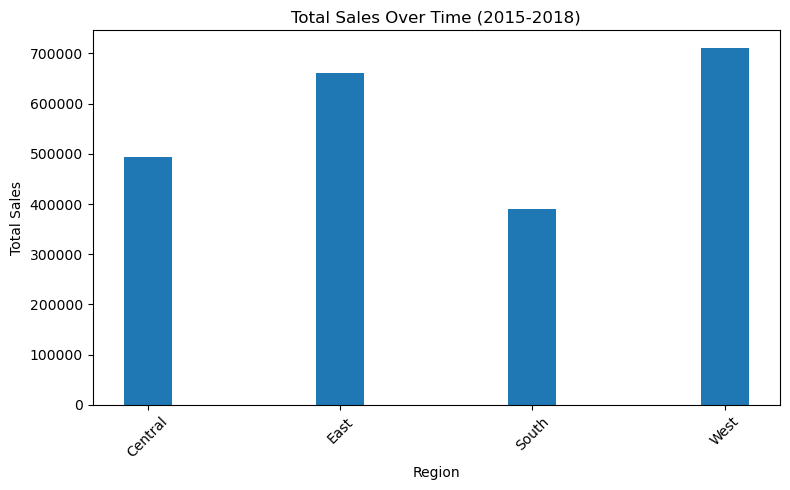

In [13]:
plt.figure(figsize=(8,5))
plt.bar(regional_sales['Region'],regional_sales['Total Sales'], width=0.25)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales Over Time (2015-2018)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here we can see that the sales are highest in the West, followed by East, Central and South respectively.

## Regional Sales over time

In [40]:
regions = ['Central', 'East', 'South', 'West']
regional_sales = {}

for r in regions:
    regional_sales[r] =  sales_data[sales_data['Region'] == r].groupby([sales_data['Order Date'].dt.year.rename('Year')])['Sales'].sum().reset_index()

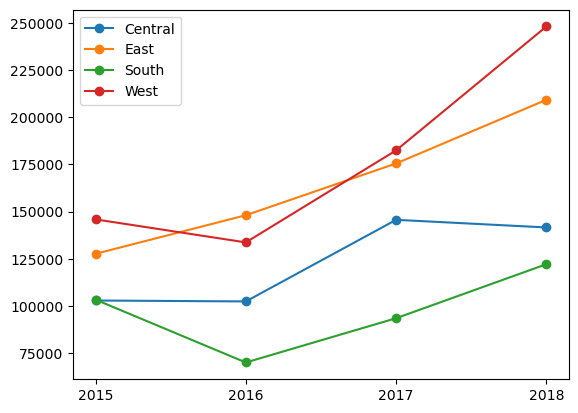

In [41]:
for r in regions:
    plt.plot(regional_sales[r]['Year'], regional_sales[r]['Sales'], label=r, marker = 'o')
plt.legend()
plt.xticks(regional_sales['Central']['Year'])
plt.show()

In [ ]:
# checking monthly performance per region

### 2. Sales by Category and Sub-category

In [17]:
# check categories
print(f"The categories are {set(sales_data['Category'])}.")

The categories are {'Office Supplies', 'Furniture', 'Technology'}.


In [22]:
category_sales = sales_data.groupby(sales_data['Category'])['Sales'].sum().reset_index()
category_sales.columns = ['Category', 'Total Sales']
category_sales

,Category,Total Sales
0,Furniture,723538.4757
1,Office Supplies,703212.8240
2,Technology,825856.1130


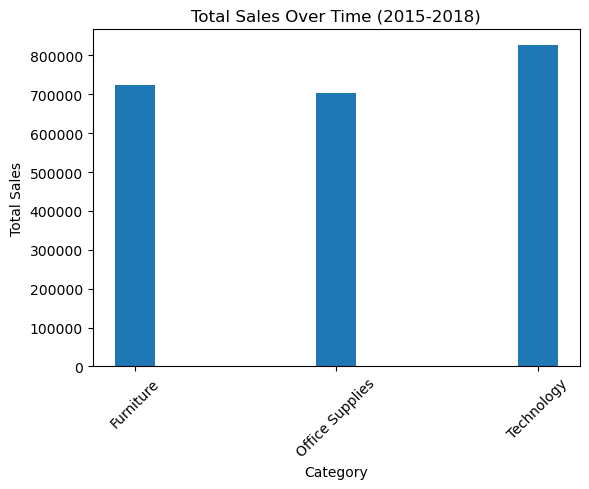

In [24]:
plt.figure(figsize=(6,5))
plt.bar(category_sales['Category'],category_sales['Total Sales'], width=0.2)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Total Sales Over Time (2015-2018)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here we can see that most products are sold within the technology category followed by Furniture and Office Supplies respectively.

### 3. Top Customers

## Next Steps

- Stage 3: Trend & timing - seasonality, shipping delays
- Stage 4: Forecasting - simple monthly sales forecast (stretch goal)